### Smart Hybrid Renewable Energy Forecasting & Grid Management System ###

### important Library ###

In [28]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import os
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import warnings
import streamlit as st

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [29]:
import os
import glob
import pandas as pd

ts_folder = 'GreenFlux15Minute'

try:
    all_ts_files = sorted(
        glob.glob(os.path.join(ts_folder, "*.xlsx")) + glob.glob(os.path.join(ts_folder, "*.csv"))
    )
except AttributeError:
    all_ts_files = sorted(
        glob(os.path.join(ts_folder, "*.xlsx")) + glob(os.path.join(ts_folder, "*.csv"))
    )

print(f"Number of detected files: {len(all_ts_files)}")

ts_dfs = []
for file in all_ts_files:
    if file.endswith('.xlsx'):
        ts_dfs.append(pd.read_excel(file))
    elif file.endswith('.csv'):
        ts_dfs.append(pd.read_csv(file))

if ts_dfs:
    df_ts = pd.concat(ts_dfs, ignore_index=True)

    time_col = [col for col in df_ts.columns if 'time' in col.lower() or 'date' in col.lower()][0]
    df_ts[time_col] = pd.to_datetime(df_ts[time_col])
    df_ts = df_ts.sort_values(by=time_col).reset_index(drop=True)

    print("Time-series data format:", df_ts.shape)
    display(df_ts.head(3))
else:
    print("No files found in the specified directory.")

Number of detected files: 1
Time-series data format: (8359844, 9)


,ChargerID,GroupID,TransactionID,StartTime,UTC_AdjustedStartTime,EndTime,UTC_AdjustedEndTime,Allocated,Avg_Amps_Drawn
0,UK-GFX-ENA0001,NaN,0,2017-01-13 11:00:00,2017-01-13 11:00:00.000,2017-01-13 11:14:59.000,2017-01-13 11:14:59.000,0,NaN
1,UK-GFX-ENA0002,NaN,0,2017-01-13 11:15:00,2017-01-13 11:15:00.000,2017-01-13 11:29:59.000,2017-01-13 11:29:59.000,0,NaN
2,UK-GFX-ENA0001,NaN,0,2017-01-13 11:15:00,2017-01-13 11:15:00.000,2017-01-13 11:29:59.000,2017-01-13 11:29:59.000,0,NaN


In [30]:
df_chargers = pd.read_excel('ChargerInstall.xlsx')
df_groups = pd.read_excel('GroupDefinition.xlsx')
df_capacity = pd.read_excel('CapacityProfile.xlsx')
df_tx = pd.read_excel('GreenFlux Transactions.xlsx')

print("The metadata files have been successfully uploaded.")

The metadata files have been successfully uploaded.


In [31]:

merged_df = df_ts.copy()

if 'ChargerID' in merged_df.columns and 'ChargerID' in df_chargers.columns:
    merged_df = pd.merge(merged_df, df_chargers, on='ChargerID', how='left')

if 'GroupID' in merged_df.columns and 'GroupID' in df_groups.columns:
    merged_df = pd.merge(merged_df, df_groups, on='GroupID', how='left')

print("Table dimensions after merging:", merged_df.shape)
merged_df.head(3)

Table dimensions after merging: (8359844, 9)


,ChargerID,GroupID,TransactionID,StartTime,UTC_AdjustedStartTime,EndTime,UTC_AdjustedEndTime,Allocated,Avg_Amps_Drawn
0,UK-GFX-ENA0001,NaN,0,2017-01-13 11:00:00,2017-01-13 11:00:00.000,2017-01-13 11:14:59.000,2017-01-13 11:14:59.000,0,NaN
1,UK-GFX-ENA0002,NaN,0,2017-01-13 11:15:00,2017-01-13 11:15:00.000,2017-01-13 11:29:59.000,2017-01-13 11:29:59.000,0,NaN
2,UK-GFX-ENA0001,NaN,0,2017-01-13 11:15:00,2017-01-13 11:15:00.000,2017-01-13 11:29:59.000,2017-01-13 11:29:59.000,0,NaN


In [32]:
merged_df['hour'] = merged_df[time_col].dt.hour
merged_df['dayofweek'] = merged_df[time_col].dt.dayofweek
merged_df['is_weekend'] = merged_df['dayofweek'].isin([5, 6]).astype(int)

merged_df['hour_sin'] = np.sin(2 * np.pi * merged_df['hour'] / 24.0)
merged_df['hour_cos'] = np.cos(2 * np.pi * merged_df['hour'] / 24.0)

merged_df['month'] = merged_df[time_col].dt.month
merged_df['month_sin'] = np.sin(2 * np.pi * merged_df['month'] / 12.0)
merged_df['month_cos'] = np.cos(2 * np.pi * merged_df['month'] / 12.0)

In [33]:

target_col = 'Power_kW' if 'Power_kW' in merged_df.columns else merged_df.select_dtypes(include=np.number).columns[0]

group_col = 'ChargerID' if 'ChargerID' in merged_df.columns else None

if group_col:
    # Lags
    merged_df['lag_15min'] = merged_df.groupby(group_col)[target_col].shift(1)
    merged_df['lag_1h'] = merged_df.groupby(group_col)[target_col].shift(4)
    merged_df['lag_24h'] = merged_df.groupby(group_col)[target_col].shift(96)
    
    merged_df['rolling_mean_2h'] = (
        merged_df.groupby(group_col)[target_col]
        .rolling(window=8, closed='left').mean().reset_index(0, drop=True)
    )
else:
    merged_df['lag_15min'] = merged_df[target_col].shift(1)
    merged_df['lag_1h'] = merged_df[target_col].shift(4)
    merged_df['lag_24h'] = merged_df[target_col].shift(96)
    merged_df['rolling_mean_2h'] = merged_df[target_col].rolling(window=8, closed='left').mean()

merged_df = merged_df.dropna().reset_index(drop=True)
print("Data readiness after feature extraction:", merged_df.shape)

Data readiness after feature extraction: (1115623, 21)


In [34]:
split_idx = int(len(merged_df) * 0.8)

train_df = merged_df.iloc[:split_idx]
test_df = merged_df.iloc[split_idx:]

print(f"Training volume (Train): {len(train_df)}")
print(f"Test size (Test): {len(test_df)}")

Training volume (Train): 892498
Test size (Test): 223125


In [35]:

target = 'Power_kW' 

drop_cols = [target, time_col, 'ChargerID', 'GroupID']  
features = [col for col in merged_df.columns if col not in drop_cols and np.issubdtype(merged_df[col].dtype, np.number)]

X_train = train_df[features]
# Use a real target column from the available dataset; 'Power_kW' does not exist here.
target_candidates = ['Power_kW', 'Avg_Amps_Drawn', 'Allocated']
target = next((c for c in target_candidates if c in merged_df.columns), None)

if target is None:
    numeric_cols = [
        c for c in merged_df.columns
        if c not in [time_col, 'ChargerID', 'GroupID', 'TransactionID']
        and np.issubdtype(merged_df[c].dtype, np.number)
    ]
    if not numeric_cols:
        raise ValueError("No valid target column found in merged_df.")
    target = numeric_cols[0]

drop_cols = [target, time_col, 'ChargerID', 'GroupID']
features = [
    c for c in merged_df.columns
    if c not in drop_cols and np.issubdtype(merged_df[c].dtype, np.number)
]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print(f"Number of selected features: {len(features)}")
print("Features:", features)

Number of selected features: 14
Features: ['TransactionID', 'Allocated', 'hour', 'dayofweek', 'is_weekend', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos', 'lag_15min', 'lag_1h', 'lag_24h', 'rolling_mean_2h']


In [36]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

[0]	validation_0-rmse:10.50794
[50]	validation_0-rmse:7.37130
[100]	validation_0-rmse:7.19922
[150]	validation_0-rmse:7.37953
[200]	validation_0-rmse:7.55877
[250]	validation_0-rmse:7.56437
[299]	validation_0-rmse:7.69236


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.3f} kW")
print(f"RMSE : {rmse:.3f} kW")
print(f"R²   : {r2:.3f}")

MAE  : 5.541 kW
RMSE : 7.692 kW
R²   : 0.458


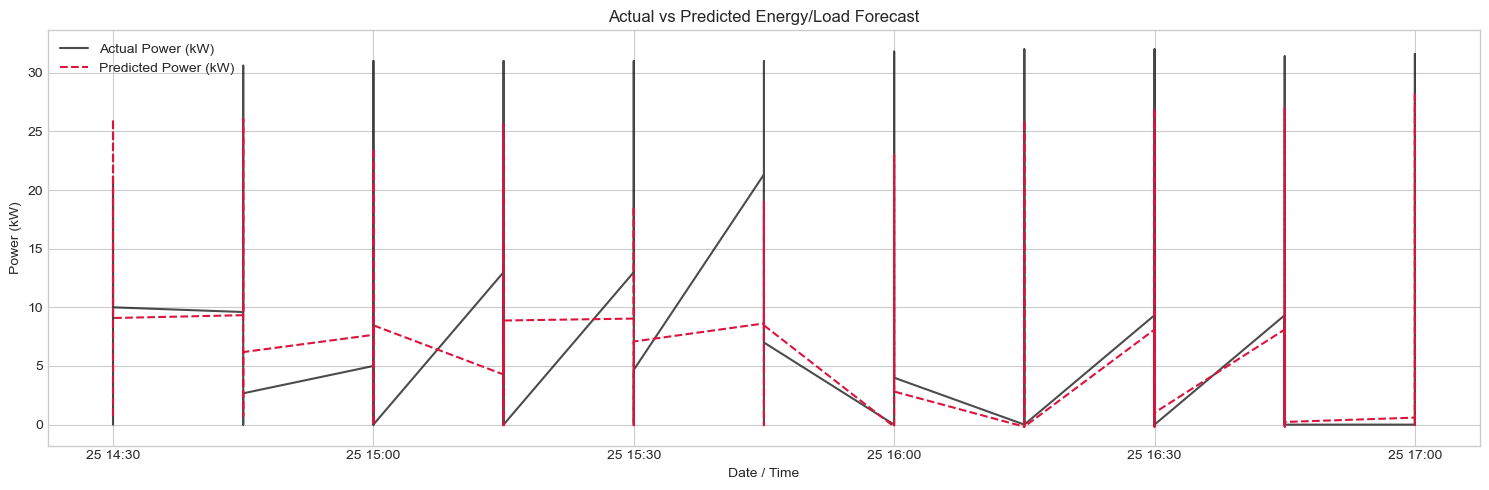

In [38]:
plt.figure(figsize=(15, 5))
sample_range = slice(0, 96 * 3)  

plt.plot(test_df[time_col].iloc[sample_range], y_test.iloc[sample_range], label='Actual Power (kW)', color='black', alpha=0.7)
plt.plot(test_df[time_col].iloc[sample_range], y_pred[sample_range], label='Predicted Power (kW)', color='crimson', linestyle='--')

plt.title('Actual vs Predicted Energy/Load Forecast')
plt.xlabel('Date / Time')
plt.ylabel('Power (kW)')
plt.legend()
plt.tight_layout()
plt.show()

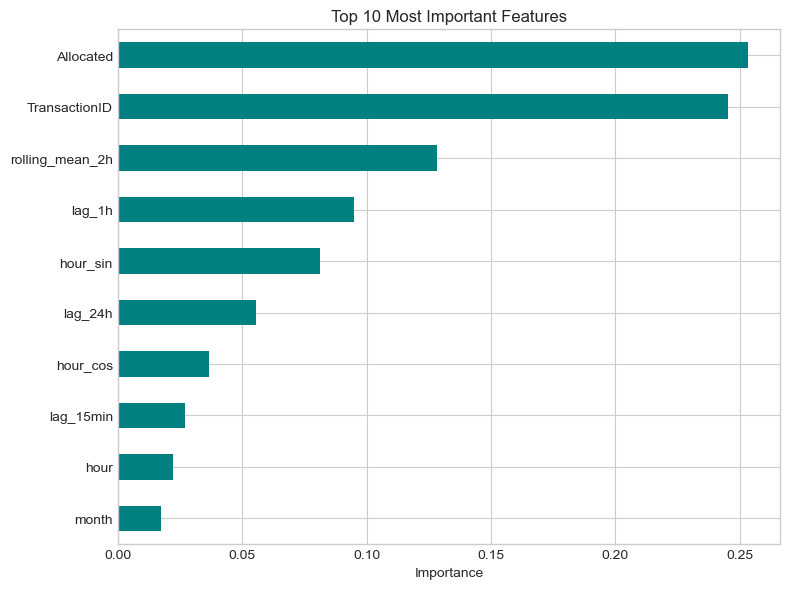

In [39]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importance.tail(10).plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [40]:
import joblib

model_payload = {
    'model': model,
    'features': features
}

joblib.dump(model_payload, 'energy_forecasting_model.pkl')
print("The model was successfully saved as energy_forecasting_model.pkl")

The model was successfully saved as energy_forecasting_model.pkl


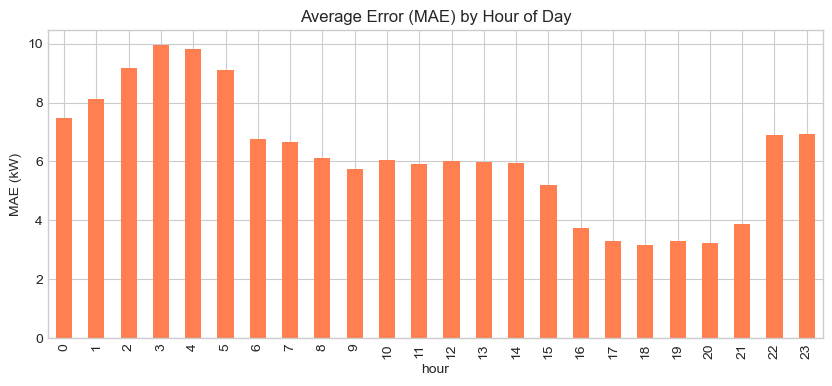

In [41]:
residuals = y_test - y_pred

error_df = pd.DataFrame({
    'hour': test_df['hour'],
    'absolute_error': np.abs(residuals)
})

hourly_error = error_df.groupby('hour')['absolute_error'].mean()

plt.figure(figsize=(10, 4))
hourly_error.plot(kind='bar', color='coral')
plt.title('Average Error (MAE) by Hour of Day')
plt.ylabel('MAE (kW)')
plt.show()

In [42]:
MAX_GRID_LIMIT = 50.0  # kW

overload_risk = y_pred > MAX_GRID_LIMIT
print(f"Number of periods during which the network capacity is expected to be exceeded:: {np.sum(overload_risk)}")

Number of periods during which the network capacity is expected to be exceeded:: 0


In [43]:
from matplotlib import projections
import streamlit as st
import joblib
import pandas as pd

st.title("⚡ Smart Energy Forecasting Dashboard")
uploaded_file = st.file_uploader("Upload Today's Sensor Data (Excel/CSV)")

if uploaded_file:
    model_data = joblib.load('energy_forecasting_model.pkl')
    st.line_chart(projections)

2026-10-01 14:42:59.747 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-01 14:42:59.749 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-01 14:42:59.753 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-01 14:42:59.755 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-01 14:42:59.756 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-01 14:42:59.758 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-01 14:42:59.765 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-01 14:42:59.767 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [44]:
print("Time series columns:")
print(df_ts.columns.tolist())

print("\nPercentage of missing values:")
print(df_ts.isnull().mean() * 100)

Time series columns:
['ChargerID', 'GroupID', 'TransactionID', 'StartTime', 'UTC_AdjustedStartTime', 'EndTime', 'UTC_AdjustedEndTime', 'Allocated', 'Avg_Amps_Drawn']

Percentage of missing values:
ChargerID                 0.000000
GroupID                  10.115942
TransactionID             0.000000
StartTime                 0.000000
UTC_AdjustedStartTime     0.000000
EndTime                   0.000000
UTC_AdjustedEndTime       0.000000
Allocated                 0.000000
Avg_Amps_Drawn           85.685020
dtype: float64


In [45]:
df_chargers = pd.read_excel('ChargerInstall.xlsx')
df_groups = pd.read_excel('GroupDefinition.xlsx')
df_capacity = pd.read_excel('CapacityProfile.xlsx')
df_tx = pd.read_excel('GreenFlux Transactions.xlsx')

print("Columns ChargerInstall:", df_chargers.columns.tolist())
print("Columns GroupDefinition:", df_groups.columns.tolist())
print("Columns CapacityProfile:", df_capacity.columns.tolist())
print("Columns Transactions:", df_tx.columns.tolist())

Columns ChargerInstall: ['ParticipantID', 'Charger', 'ChargerInstallDate', 'DCSProvider', 'CarInstallDate', 'CarMake', 'CarModel', 'PIVType', 'CarkW', 'CarkWh']
Columns GroupDefinition: []
Columns CapacityProfile: []
Columns Transactions: ['TransactionID', 'ChargerID', 'ParticipantID', 'ParticipantCarkW', 'ParticipantCarkWh', 'StartTime', 'StopTime', 'GroupID', 'Trial', 'AdjustedStartTime', 'AdjustedStopTime', 'PluggedInTime', 'ConsumedkWh', 'PartOfManagedGroup', 'WeekdayOrWeekend', 'ActiveChargingStart', 'MaxAmpsDrawnForT', 'EndCharge', 'ChargingDuration', 'tInactiveStart', 'tInactiveEnd', 'UsedATimer', 'BeganInWeekdayEveningPeak', 'HotUnplug', 'Managed', 'PercentageTimeInTransactionManaged']


In [46]:
merged_df = df_ts.copy()

charger_id_col = next((c for c in ['ChargerID', 'charger_id', 'DeviceID'] if c in merged_df.columns), None)
if charger_id_col and charger_id_col in df_chargers.columns:
    merged_df = pd.merge(merged_df, df_chargers, on=charger_id_col, how='left')

group_id_col = next((c for c in ['GroupID', 'group_id'] if c in merged_df.columns), None)
if group_id_col and group_id_col in df_groups.columns:
    merged_df = pd.merge(merged_df, df_groups, on=group_id_col, how='left')

print("DataFrame dimensions after merging:", merged_df.shape)
merged_df.head(3)

DataFrame dimensions after merging: (8359844, 9)


,ChargerID,GroupID,TransactionID,StartTime,UTC_AdjustedStartTime,EndTime,UTC_AdjustedEndTime,Allocated,Avg_Amps_Drawn
0,UK-GFX-ENA0001,NaN,0,2017-01-13 11:00:00,2017-01-13 11:00:00.000,2017-01-13 11:14:59.000,2017-01-13 11:14:59.000,0,NaN
1,UK-GFX-ENA0002,NaN,0,2017-01-13 11:15:00,2017-01-13 11:15:00.000,2017-01-13 11:29:59.000,2017-01-13 11:29:59.000,0,NaN
2,UK-GFX-ENA0001,NaN,0,2017-01-13 11:15:00,2017-01-13 11:15:00.000,2017-01-13 11:29:59.000,2017-01-13 11:29:59.000,0,NaN


In [47]:
import numpy as np

merged_df['hour'] = merged_df[time_col].dt.hour
merged_df['dayofweek'] = merged_df[time_col].dt.dayofweek
merged_df['is_weekend'] = merged_df['dayofweek'].isin([5, 6]).astype(int)

merged_df['hour_sin'] = np.sin(2 * np.pi * merged_df['hour'] / 24.0)
merged_df['hour_cos'] = np.cos(2 * np.pi * merged_df['hour'] / 24.0)

merged_df['month'] = merged_df[time_col].dt.month
merged_df['month_sin'] = np.sin(2 * np.pi * merged_df['month'] / 12.0)
merged_df['month_cos'] = np.cos(2 * np.pi * merged_df['month'] / 12.0)

target_candidates = [col for col in merged_df.columns if any(k in col.lower() for k in ['power', 'kw', 'load', 'energy', 'demand'])]
target_col = target_candidates[0] if target_candidates else merged_df.select_dtypes(include=np.number).columns[0]
print(f"The selected target variable is: {target_col}")

group_col = next((c for c in ['ChargerID', 'charger_id', 'DeviceID'] if c in merged_df.columns), None)

if group_col:
    merged_df['lag_1'] = merged_df.groupby(group_col)[target_col].shift(1)
    merged_df['lag_4'] = merged_df.groupby(group_col)[target_col].shift(4)
    merged_df['lag_96'] = merged_df.groupby(group_col)[target_col].shift(96)
    
    merged_df['rolling_mean_2h'] = (
        merged_df.groupby(group_col)[target_col]
        .rolling(window=8, closed='left').mean().reset_index(0, drop=True)
    )
else:
    merged_df['lag_1'] = merged_df[target_col].shift(1)
    merged_df['lag_4'] = merged_df[target_col].shift(4)
    merged_df['lag_96'] = merged_df[target_col].shift(96)
    merged_df['rolling_mean_2h'] = merged_df[target_col].rolling(window=8, closed='left').mean()

df_model = merged_df.dropna().reset_index(drop=True)

split_point = int(len(df_model) * 0.8)
train_df = df_model.iloc[:split_point]
test_df = df_model.iloc[split_point:]

drop_cols = [target_col, time_col]
if group_col:
    drop_cols.append(group_col)

feature_cols = [col for col in df_model.columns if col not in drop_cols and np.issubdtype(df_model[col].dtype, np.number)]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Features used ({len(feature_cols)}):", feature_cols)

The selected target variable is: TransactionID

Training set size: (892498, 14)
Test set size: (223125, 14)
Features used (14): ['Allocated', 'Avg_Amps_Drawn', 'hour', 'dayofweek', 'is_weekend', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos', 'lag_1', 'lag_4', 'lag_96', 'rolling_mean_2h']


Starting model training...
Training completed successfully!

--- Performance Metrics ---
Mean Absolute Error (MAE) : 12088.907
Root Mean Squared Error (RMSE): 17137.631
R² Score                  : -0.037


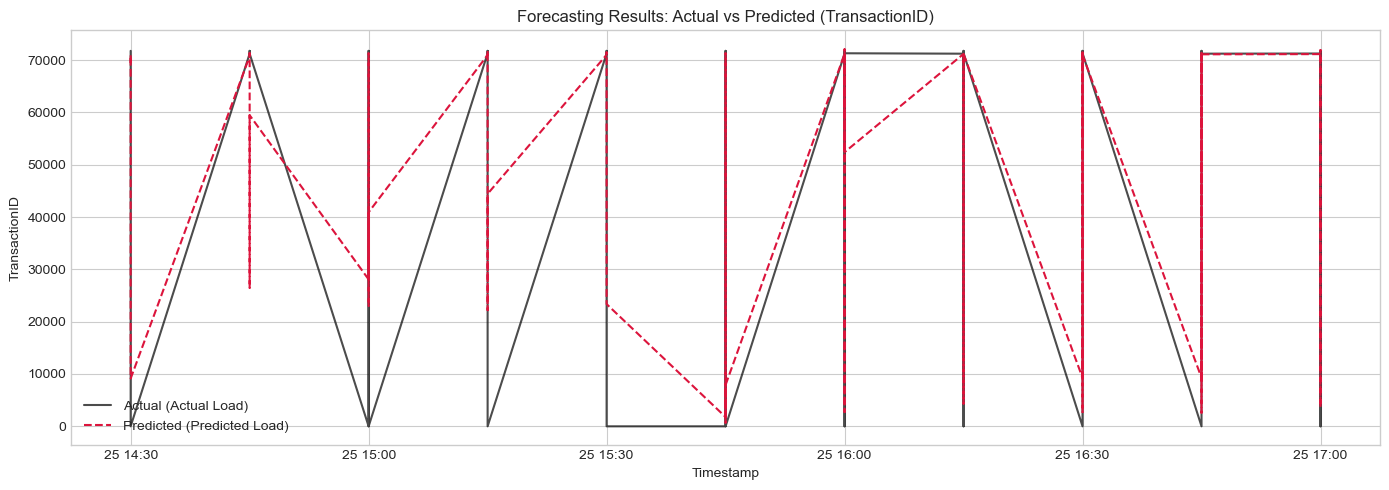

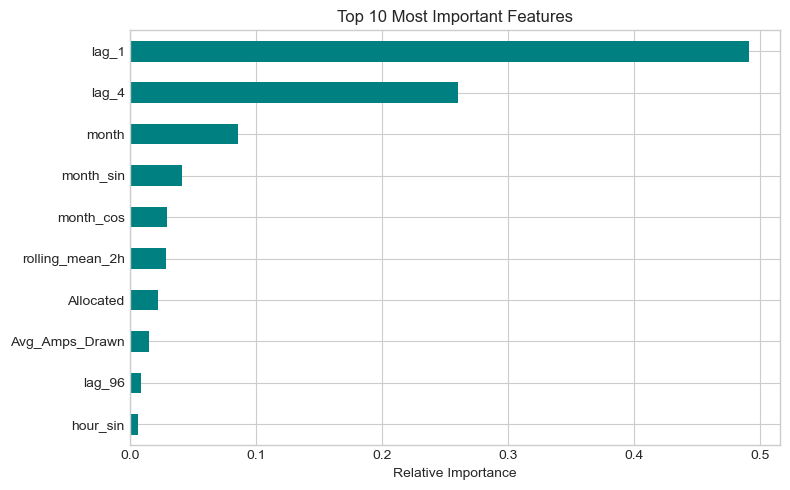

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

print("Starting model training...")
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)
print("Training completed successfully!")
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- Performance Metrics ---")
print(f"Mean Absolute Error (MAE) : {mae:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R² Score                  : {r2:.3f}")

plt.figure(figsize=(14, 5))
sample_steps = min(len(y_test), 96 * 3)  

plt.plot(
    test_df[time_col].iloc[:sample_steps], 
    y_test.iloc[:sample_steps].values, 
    label='Actual (Actual Load)',
    color='black', 
    alpha=0.7
)
plt.plot(
    test_df[time_col].iloc[:sample_steps], 
    y_pred[:sample_steps], 
    label='Predicted (Predicted Load)', 
    color='crimson', 
    linestyle='--'
)

plt.title(f'Forecasting Results: Actual vs Predicted ({target_col})')
plt.xlabel('Timestamp')
plt.ylabel(target_col)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
feat_imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
feat_imp.tail(10).plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Features')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

Model saved successfully in file: energy_forecast_xgb.pkl


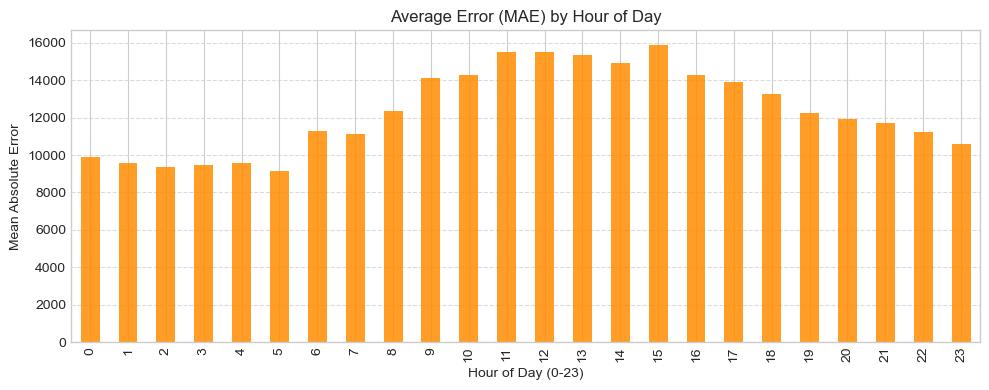

Capacity Threshold: 68052.00
Number of periods with predicted load exceeding capacity: 157750 out of 223125


In [49]:
import joblib

model_bundle = {
    'model': model,
    'features': feature_cols,
    'target_col': target_col,
    'metrics': {'mae': mae, 'rmse': rmse, 'r2': r2}
}

joblib.dump(model_bundle, 'energy_forecast_xgb.pkl')
print("Model saved successfully in file: energy_forecast_xgb.pkl")

residuals = y_test.values - y_pred
analysis_df = pd.DataFrame({
    'hour': test_df['hour'].values,
    'abs_error': np.abs(residuals)
})

hourly_mae = analysis_df.groupby('hour')['abs_error'].mean()

plt.figure(figsize=(10, 4))
hourly_mae.plot(kind='bar', color='darkorange', alpha=0.85)
plt.title('Average Error (MAE) by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Mean Absolute Error')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

capacity_limit = y_train.quantile(0.95)
overload_alerts = y_pred > capacity_limit

print(f"Capacity Threshold: {capacity_limit:.2f}")
print(f"Number of periods with predicted load exceeding capacity: {np.sum(overload_alerts)} out of {len(y_pred)}")

In [50]:
results_df = test_df[[time_col]].copy()
results_df['Actual_Load'] = y_test.values
results_df['Predicted_Load'] = np.round(y_pred, 3)
results_df['Error'] = np.round(results_df['Actual_Load'] - results_df['Predicted_Load'], 3)
results_df['Capacity_Exceeded'] = (results_df['Predicted_Load'] > capacity_limit).astype(int)

output_path = 'forecasting_test_results.csv'
results_df.to_csv(output_path, index=False)
print(f"Results fully exported to: {output_path}")
display(results_df.head(10))

def forecast_new_data(raw_new_df, model_path='energy_forecast_xgb.pkl'):
    # تحميل النموذج والميزات
    bundle = joblib.load(model_path)
    loaded_model = bundle['model']
    required_features = bundle['features']
    
    X_new = raw_new_df[required_features]
    predictions = loaded_model.predict(X_new)
    return predictions

print("\nForecast function forecast_new_data() is ready for use in any production environment.")

Results fully exported to: forecasting_test_results.csv


,StartTime,Actual_Load,Predicted_Load,Error,Capacity_Exceeded
892498,2018-09-25 14:30:00,71758,69428.062500,2329.938,1
892499,2018-09-25 14:30:00,71231,70971.679688,259.320,1
892500,2018-09-25 14:30:00,0,9132.627930,-9132.628,0
892501,2018-09-25 14:45:00,71209,70733.757812,475.242,1
892502,2018-09-25 14:45:00,71211,70959.867188,251.133,1
892503,2018-09-25 14:45:00,71220,70906.648438,313.352,1
892504,2018-09-25 14:45:00,71316,26472.986328,44843.014,0
892505,2018-09-25 14:45:00,71202,70895.070312,306.930,1
892506,2018-09-25 14:45:00,71232,71253.648438,-21.648,1
892507,2018-09-25 14:45:00,71347,70668.554688,678.445,1



Forecast function forecast_new_data() is ready for use in any production environment.
